# Ablation Study Analysis

This notebook analyses the results produced by `scripts/run_ablations.py`.
Each experiment systematically removes one algorithmic component to quantify
its individual contribution to the final Pareto-front quality.

---

## Experiments

| ID | Config file | Component removed | Expected effect |
|----|-------------|-------------------|-----------------|
| T1 | `full_proposed.json` | — (full system) | Best HV / lowest IGD |
| T2 | `ablation_t2_no_pso.json` | PSO local refinement | Loss of topology-safe local search |
| T3 | `ablation_t3_no_ga.json` | GA global mutation | Loss of global exploration diversity |
| T4 | `ablation_t4_no_moead.json` | MOEA/D decomposition ($K=1$) | Collapse to single-direction search |
| T5 | `ablation_t5_no_sa.json` | Simulated Annealing | Greedy-only acceptance, local optima |
| T6 | `ablation_t6_no_restart.json` | Diversity restart | Premature convergence |

---

## Metrics

- **Hypervolume (HV)** — higher is better.  
  $$\text{HV}(A, r) = \lambda\!\left(\bigcup_{a \in A} [f_1(a),\, r_1] \times [f_2(a),\, r_2]\right)$$
- **IGD** — lower is better.  
  $$\text{IGD}(A, P^{\ast}) = \frac{1}{|P^{\ast}|}\sum_{p \in P^{\ast}} \min_{a \in A} \lVert p - a \rVert_2$$
- **Pareto size** — number of non-dominated solutions in the aggregate front.

Results files: `results/ablations/{experiment_name}_seed{N}.json`

In [ ]:
# ── Setup ────────────────────────────────────────────────────────────────────
import sys
import functools
from pathlib import Path

# ── Bootstrap: find project root before any src imports ──────────────────────
_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / "src").exists() and (_parent / "requirements.txt").exists():
        PROJECT_ROOT = _parent
        break
else:
    PROJECT_ROOT = _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd, proxy_pareto,
)
from src.analysis.data_loader import load_ablation_archives as _load_ablation_archives
from src.utils.pareto_math import compute_bounds, normalise_to_bounds

ABLATION_DIR = PROJECT_ROOT / "results" / "ablations"
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

EXPERIMENT_ORDER = [
    ("full_proposed", "T1 — Full Proposed"),
    ("no_pso",        "T2 — No PSO"),
    ("no_ga",         "T3 — No GA"),
    ("no_moead",      "T4 — No MOEA/D"),
    ("no_sa",         "T5 — No SA"),
    ("no_restart",    "T6 — No Restart"),
]
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

load_ablation_archives = functools.partial(_load_ablation_archives, ABLATION_DIR)

print("Results directory:", ABLATION_DIR)
print("Run `python scripts/run_ablations.py` first if no results appear below.\n")

available = {name: load_ablation_archives(name) for name, _ in EXPERIMENT_ORDER}
for name, label in EXPERIMENT_ORDER:
    print(f"  {label:30s}  {len(available[name])} seed(s) found")


Results directory: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablations
Run `python scripts/run_ablations.py` first if no results appear below.

  T1 — Full Proposed              30 seed(s) found
  T2 — No PSO                     30 seed(s) found
  T3 — No GA                      30 seed(s) found
  T4 — No MOEA/D                  30 seed(s) found
  T5 — No SA                      30 seed(s) found
  T6 — No Restart                 30 seed(s) found


In [ ]:
# ── Step 2: Build global proxy P* from all ablation runs ──────────────────────
# proxy_pareto() pre-filters each archive to its own front before pooling,
# so the union is tiny and the final get_pareto_front() call is memory-safe.
all_archives_flat = [a for arcs in available.values() for a in arcs]
if not all_archives_flat:
    raise RuntimeError("No ablation results found. Run scripts/run_ablations.py first.")

p_star = proxy_pareto(all_archives_flat)

_pts_min, _pts_range = compute_bounds(p_star)
normalise = lambda pts: normalise_to_bounds(pts, _pts_min, _pts_range)

REF = np.array([1.1, 1.1])

pts_max = _pts_min + _pts_range
print(f"Proxy P* size : {len(p_star)} non-dominated solutions")
print(f"Objective bounds  f1 ∈ [{_pts_min[0]:.4f}, {pts_max[0]:.4f}]  "
      f"f2 ∈ [{_pts_min[1]:.4f}, {pts_max[1]:.4f}]")
print(f"Reference point (normalised space): {REF}")


Proxy P* size : 44680 non-dominated solutions
Objective bounds  f1 ∈ [-94.3733, -10.0000]  f2 ∈ [0.5014, 6.7722]
Reference point (normalised space): [1.1 1.1]


In [9]:
# ── Step 3: Hypervolume & IGD per seed → tidy DataFrame ───────────────────
# One row per (experiment × seed) so seaborn and scipy can work directly
# on the raw per-seed values.  Global normalisation is applied before every
# HV / IGD call so scores are comparable across experiments.

records = []
for (name, label), color in zip(EXPERIMENT_ORDER, COLORS):
    for seed_idx, run in enumerate(available[name]):
        pts   = archive_to_points(run)
        front = get_pareto_front(pts)
        nf    = normalise(front)          # ← global bounds, not local!
        records.append({
            "experiment": name,
            "label":      label.split(" — ")[1],
            "seed":       seed_idx,
            "hv":         calc_hv(nf, ref_point=REF),
            "igd":        calc_igd(nf, normalise(p_star)),
        })

df_raw = pd.DataFrame(records)

# ── Summary table ─────────────────────────────────────────────────────────
summary = (
    df_raw.groupby(["experiment", "label"], sort=False)
    .agg(seeds=("seed", "count"), hv_mean=("hv", "mean"), hv_std=("hv", "std"),
         igd_mean=("igd", "mean"), igd_std=("igd", "std"))
    .reset_index()
)
summary["HV (mean ± std)"]  = summary.apply(
    lambda r: f"{r.hv_mean:.4f} ± {r.hv_std:.4f}", axis=1)
summary["IGD (mean ± std)"] = summary.apply(
    lambda r: f"{r.igd_mean:.4f} ± {r.igd_std:.4f}", axis=1)
summary["HV rank"]      = summary["hv_mean"].rank(ascending=False).astype(int)
summary["IGD rank"]     = summary["igd_mean"].rank(ascending=True).astype(int)
summary["Overall rank"] = (summary["HV rank"] + summary["IGD rank"]).rank(ascending=True).astype(int)
summary = summary.set_index("label")

print(summary[["seeds", "HV (mean ± std)", "HV rank",
               "IGD (mean ± std)", "IGD rank", "Overall rank"]].to_string())

               seeds  HV (mean ± std)  HV rank IGD (mean ± std)  IGD rank  Overall rank
label                                                                                  
Full Proposed     30  1.0468 ± 0.0011        3  0.0095 ± 0.0062         2             2
No PSO            30  1.0480 ± 0.0007        1  0.0055 ± 0.0030         1             1
No GA             30  0.8651 ± 0.1299        6  0.1226 ± 0.0378         6             6
No MOEA/D         30  1.0421 ± 0.0048        5  0.0353 ± 0.0280         5             5
No SA             30  1.0469 ± 0.0011        2  0.0097 ± 0.0071         4             3
No Restart        30  1.0468 ± 0.0011        4  0.0097 ± 0.0058         3             4


In [10]:
# ── Step 4: Wilcoxon Rank-Sum Statistical Tests ────────────────────────────
# scipy.stats.ranksums implements the two-sided Wilcoxon rank-sum test
# (equivalent to Mann-Whitney U).  H0: the two samples come from the same
# distribution.  Reject H0 at α = 0.05 to claim statistical significance.
#
# We compare the 5 HV seeds of T1 (Full Proposed) against every ablation.
# Bonferroni correction: multiply each p-value by the number of tests (5).

from scipy.stats import ranksums

hv_by_name = {
    name: df_raw.loc[df_raw["experiment"] == name, "hv"].values
    for name, _ in EXPERIMENT_ORDER
}

baseline_hv  = hv_by_name["full_proposed"]
n_comparisons = len(EXPERIMENT_ORDER) - 1          # 5 tests (T2–T6)

print("Wilcoxon Rank-Sum Test  —  T1 (Full Proposed) vs. each ablation variant")
print("H₀: distributions are identical  |  α = 0.05  |  Bonferroni-corrected α* = 0.05 / 5 = 0.010")
print()
header = f"{'Ablation':<25}  {'W-stat':>9}  {'p (raw)':>10}  {'p (Bonf.)':>10}  {'sig.':>5}  {'Δ HV mean':>10}"
print(header)
print("─" * len(header))

stat_rows = []
for name, label in EXPERIMENT_ORDER[1:]:           # skip full_proposed
    abl_hv = hv_by_name.get(name, np.array([]))
    if len(abl_hv) == 0:
        continue
    stat, p_raw      = ranksums(baseline_hv, abl_hv)
    p_bonf           = min(p_raw * n_comparisons, 1.0)
    delta_hv         = baseline_hv.mean() - abl_hv.mean()
    sig_marker       = ("***" if p_bonf < 0.001
                        else "**"  if p_bonf < 0.01
                        else "*"   if p_bonf < 0.05
                        else "n.s.")
    short = label.split(" — ")[1]
    print(f"  {short:<23}  {stat:>9.4f}  {p_raw:>10.4f}  {p_bonf:>10.4f}  {sig_marker:>5}  {delta_hv:>+10.4f}")
    stat_rows.append({"ablation": short, "W": stat, "p_raw": p_raw,
                      "p_bonf": p_bonf, "delta_hv": delta_hv})

df_stats = pd.DataFrame(stat_rows)
print()
print("*** p<0.001   ** p<0.01   * p<0.05   n.s. not significant")
print("Δ HV mean: positive = Full Proposed has higher mean HV (better)")

Wilcoxon Rank-Sum Test  —  T1 (Full Proposed) vs. each ablation variant
H₀: distributions are identical  |  α = 0.05  |  Bonferroni-corrected α* = 0.05 / 5 = 0.010

Ablation                      W-stat     p (raw)   p (Bonf.)   sig.   Δ HV mean
───────────────────────────────────────────────────────────────────────────────
  No PSO                     -4.4353      0.0000      0.0000    ***     -0.0012
  No GA                       6.6530      0.0000      0.0000    ***     +0.1818
  No MOEA/D                   5.7955      0.0000      0.0000    ***     +0.0047
  No SA                      -0.7392      0.4598      1.0000   n.s.     -0.0001
  No Restart                  0.1331      0.8941      1.0000   n.s.     +0.0000

*** p<0.001   ** p<0.01   * p<0.05   n.s. not significant
Δ HV mean: positive = Full Proposed has higher mean HV (better)


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablations_hv_boxplot.pdf


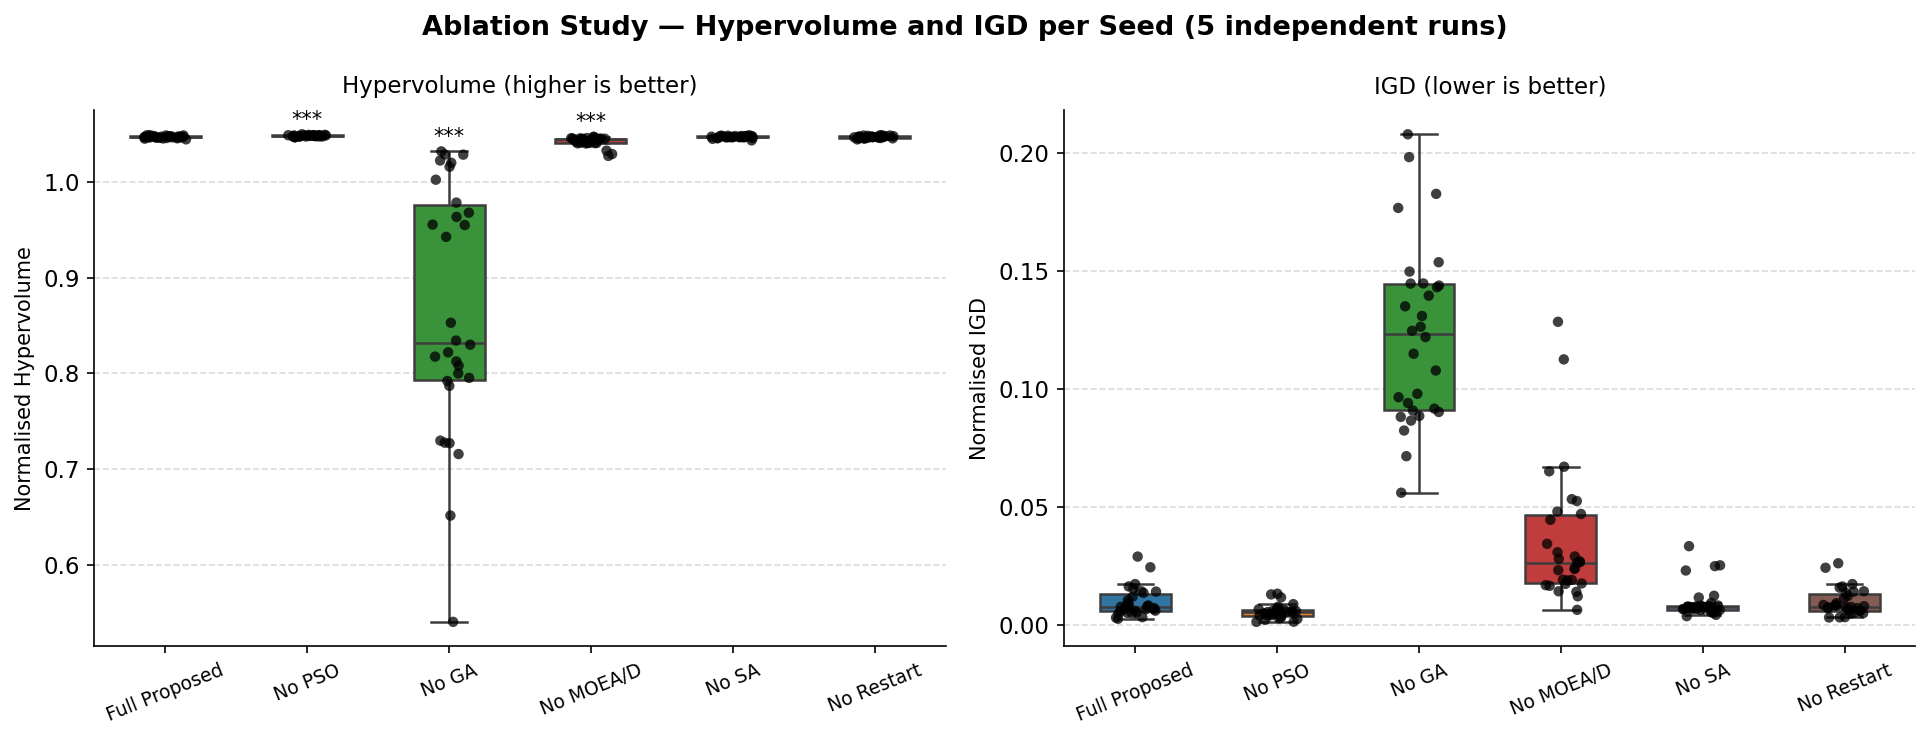

In [11]:
# ── Step 5: Seaborn HV & IGD boxplots with individual seed points ─────────
import seaborn as sns

# Preserve the EXPERIMENT_ORDER on the x-axis
exp_order = [label.split(" — ")[1]
             for name, label in EXPERIMENT_ORDER if available.get(name)]
palette   = {label.split(" — ")[1]: color
             for (_, label), color in zip(EXPERIMENT_ORDER, COLORS)
             if available.get(_)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Ablation Study — Hypervolume and IGD per Seed (5 independent runs)",
             fontweight="bold", fontsize=13)

for ax, metric, title, ylabel, ascending in [
    (axes[0], "hv",  "Hypervolume (higher is better)", "Normalised Hypervolume", False),
    (axes[1], "igd", "IGD (lower is better)",          "Normalised IGD",         True),
]:
    # Boxplot body (hue=x suppresses the palette deprecation warning in seaborn ≥0.13)
    sns.boxplot(
        data=df_raw, x="label", y=metric, hue="label", order=exp_order,
        palette=palette, width=0.5, linewidth=1.2,
        flierprops=dict(marker=""), legend=False,
        ax=ax,
    )
    # Overlay individual seed dots (jittered)
    sns.stripplot(
        data=df_raw, x="label", y=metric, hue="label", order=exp_order,
        palette=["black"] * len(exp_order), size=5, jitter=0.15, alpha=0.75,
        legend=False, ax=ax,
    )
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis="x", rotation=22, labelsize=9)
    ax.yaxis.grid(True, linestyle="--", alpha=0.45)
    ax.set_axisbelow(True)

    # Annotate significance stars above each ablation column
    if metric == "hv":
        for tick_pos, (name, label) in enumerate(EXPERIMENT_ORDER):
            short = label.split(" — ")[1]
            if name == "full_proposed" or name not in [n for n, _ in EXPERIMENT_ORDER]:
                continue
            row = df_stats[df_stats["ablation"] == short]
            if row.empty:
                continue
            sig = row.iloc[0]["p_bonf"]
            marker = ("***" if sig < 0.001
                      else "**"  if sig < 0.01
                      else "*"   if sig < 0.05 else "")
            if marker:
                y_top = df_raw.loc[df_raw["label"] == short, "hv"].max()
                ax.text(tick_pos, y_top + 0.005, marker,
                        ha="center", va="bottom", fontsize=10, color="black")

fig.tight_layout()
out = PROJECT_ROOT / "results" / "ablations_hv_boxplot.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved → {out}")
plt.show()

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablation_pareto_overlay.pdf


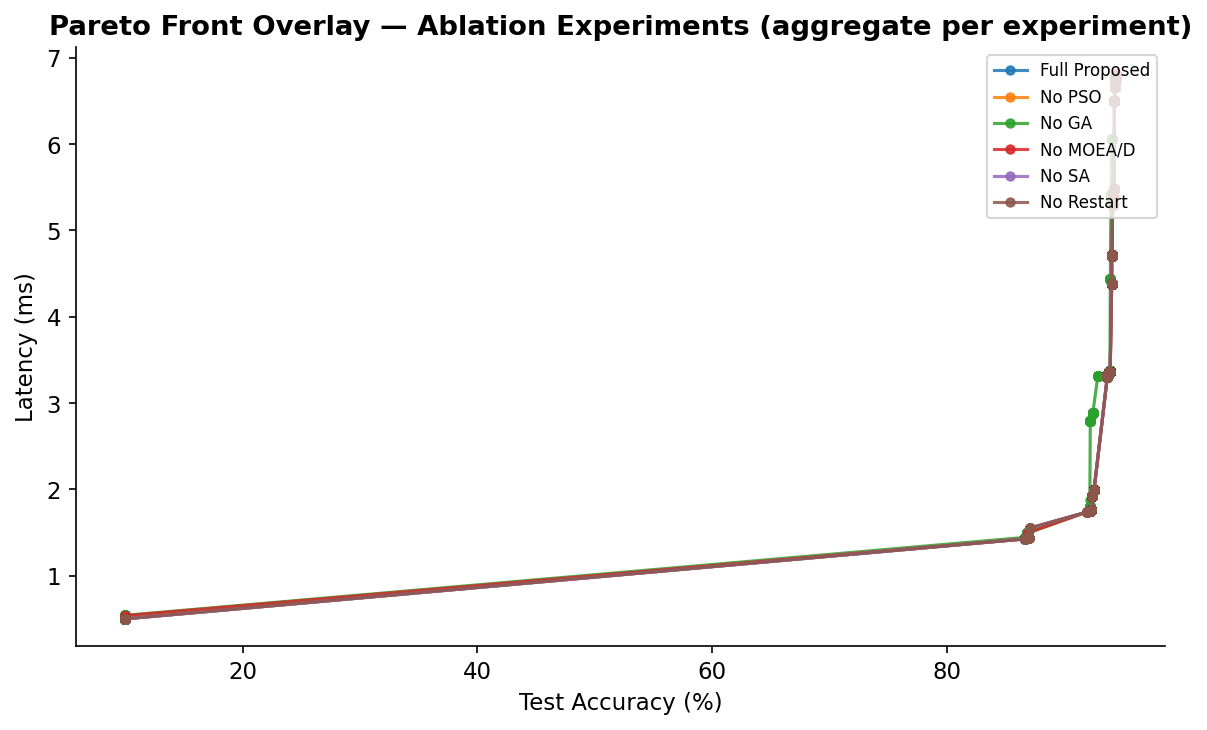

In [12]:
# ── Pareto front overlay ───────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(8, 5))
ax.set_title(
    "Pareto Front Overlay — Ablation Experiments (aggregate per experiment)",
    fontweight="bold",
)

for (name, label), color in zip(EXPERIMENT_ORDER, COLORS):
    arcs = available[name]
    if not arcs:
        continue
    all_pts = np.vstack([archive_to_points(a) for a in arcs])
    front   = get_pareto_front(all_pts)
    # Convert to display space: (-acc, lat) → (acc, lat)
    acc_display = -front[:, 0]
    lat_display =  front[:, 1]
    order = np.argsort(acc_display)
    ax.plot(
        acc_display[order], lat_display[order],
        marker="o", markersize=4, linewidth=1.5,
        color=color, label=label.split(" — ")[1], alpha=0.85,
    )

ax.set_xlabel("Test Accuracy (%)")
ax.set_ylabel("Latency (ms)")
ax.legend(fontsize=8, loc="upper right")
fig2.tight_layout()
out2 = PROJECT_ROOT / "results" / "ablation_pareto_overlay.pdf"
fig2.savefig(out2, bbox_inches="tight")
print(f"Saved → {out2}")
plt.show()